In [15]:
import os
#фикс для macos
os.environ['THREADPOOLCTL_ENABLED'] = '0'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#модели и метрики
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

#настройки
sns.set(style="whitegrid")
#игнорирование предупреждений
warnings.filterwarnings('ignore')

print("библиотеки загружены")

библиотеки загружены


In [16]:
#выбор данных и препроцессинг
try:
    #загрузка данных
    df_cls = pd.read_csv('../data/hotel_bookings.csv')
    df_reg = pd.read_csv('../data/train.csv')
except FileNotFoundError:
    print("ошибка: файлы не найдены")

#сэмплирование 
sample_size = 10000
df_cls = df_cls.sample(n=sample_size, random_state=42).copy()
df_reg = df_reg.sample(n=sample_size, random_state=42).copy()

#подготовка к классификации
y_cls = df_cls['is_canceled']
#удаление сложных колонок
X_cls = df_cls.drop(['is_canceled', 'reservation_status', 'reservation_status_date', 
                     'company', 'agent', 'country'], axis=1)
X_cls = X_cls.fillna(0)

#кодирование категорий
label_encoders_cls = {}
for col in X_cls.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_cls[col] = le.fit_transform(X_cls[col].astype(str))
    label_encoders_cls[col] = le

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

#подготовка к регрессии
y_reg = df_reg['Purchase']
X_reg = df_reg.drop(['Purchase', 'User_ID', 'Product_ID'], axis=1)
X_reg = X_reg.fillna(0)

for col in X_reg.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_reg[col] = le.fit_transform(X_reg[col].astype(str))

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("данные готовы")

данные готовы


In [17]:
#создание бейзлайна

#классификация
rf_cls_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_cls_base.fit(X_train_cls, y_train_cls)

y_pred_cls_base = rf_cls_base.predict(X_test_cls)
f1_base = f1_score(y_test_cls, y_pred_cls_base)

#регрессия
rf_reg_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_reg_base.fit(X_train_reg, y_train_reg)

y_pred_reg_base = rf_reg_base.predict(X_test_reg)
rmse_base = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_base))

print(f"baseline rf f1: {f1_base:.4f}")
print(f"baseline rf rmse: {rmse_base:.2f}")

baseline rf f1: 0.7624
baseline rf rmse: 3248.18


In [18]:
#улучшение бейзлайна

#увеличение числа деревьев и ограничение глубины улучшит обобщающую способность (???)

#параметры для gridsearch
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

#тюнинг классификации
#используем n_jobs=-1 для параллельных вычислений
grid_cls = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=3, scoring='f1', n_jobs=-1)
grid_cls.fit(X_train_cls, y_train_cls)

best_cls = grid_cls.best_estimator_
f1_impr = f1_score(y_test_cls, best_cls.predict(X_test_cls))

print(f"лучшие параметры cls: {grid_cls.best_params_}")

#тюнинг регрессии
grid_reg = GridSearchCV(RandomForestRegressor(random_state=42), params, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_reg.fit(X_train_reg, y_train_reg)

best_reg = grid_reg.best_estimator_
rmse_impr = np.sqrt(mean_squared_error(y_test_reg, best_reg.predict(X_test_reg)))

print(f"лучшие параметры reg: {grid_reg.best_params_}")

#сравнение
print("\nсравнение")
print(f"f1: {f1_base:.4f} -> {f1_impr:.4f}")
print(f"rmse: {rmse_base:.2f} -> {rmse_impr:.2f}")

лучшие параметры cls: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 200}
лучшие параметры reg: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}

сравнение
f1: 0.7624 -> 0.7623
rmse: 3248.18 -> 3290.98


In [19]:
#имплементация алгоритма
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from scipy.stats import mode

class MyRandomForest:
    def __init__(self, n_estimators=10, max_depth=None, max_features='sqrt', task_type='classification'):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.task_type = task_type
        self.trees = []
        
    def fit(self, X, y):
        #конвертация в numpy для удобства индексации
        X = np.array(X)
        y = np.array(y)
        self.trees = []
        n_samples, n_features = X.shape
        
        for _ in range(self.n_estimators):
            #bootstrap sampling (выборка с возвращением)
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_bootstrap = X[indices]
            y_bootstrap = y[indices]
            
            #создание базового дерева
            if self.task_type == 'classification':
                tree = DecisionTreeClassifier(max_depth=self.max_depth, max_features=self.max_features, random_state=None)
            else:
                tree = DecisionTreeRegressor(max_depth=self.max_depth, max_features=self.max_features, random_state=None)
            
            #обучение дерева на бутстрап-выборке
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)
            
    def predict(self, X):
        X = np.array(X)
        #получение предсказаний от всех деревьев
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        
        #транспонирование: строки - объекты, столбцы - предсказания деревьев
        tree_preds = tree_preds.T
        
        final_preds = []
        for sample_preds in tree_preds:
            if self.task_type == 'classification':
                #голосование большинством (hard voting)
                #mode возвращает массив, берем первый элемент
                res = mode(sample_preds, keepdims=True)[0][0]
                final_preds.append(res)
            else:
                #успреднение для регрессии
                res = np.mean(sample_preds)
                final_preds.append(res)
                
        return np.array(final_preds)

In [20]:
#тест своего классификатора

#берем 20 деревьев для скорости
print("обучение my_rf_cls...")
my_rf_cls = MyRandomForest(n_estimators=20, max_depth=15, task_type='classification')
my_rf_cls.fit(X_train_cls, y_train_cls)

y_pred_my_cls = my_rf_cls.predict(X_test_cls)
f1_my = f1_score(y_test_cls, y_pred_my_cls)

#тест своего регрессора
print("обучение my_rf_reg...")
my_rf_reg = MyRandomForest(n_estimators=20, max_depth=15, task_type='regression')
my_rf_reg.fit(X_train_reg, y_train_reg)

y_pred_my_reg = my_rf_reg.predict(X_test_reg)
rmse_my = np.sqrt(mean_squared_error(y_test_reg, y_pred_my_reg))

обучение my_rf_cls...
обучение my_rf_reg...


In [24]:
#итоговая таблица
results = pd.DataFrame({
    'model': ['baseline', 'improved (tuned)', 'my implementation'],
    'f1_score': [f1_base, f1_impr, f1_my],
    'rmse': [rmse_base, rmse_impr, rmse_my]
})

print("\nрезультаты")
display(results)


результаты


,model,f1_score,rmse
0,baseline,0.762391,3248.180294
1,improved (tuned),0.762253,3290.978406
2,my implementation,0.732778,3346.023314


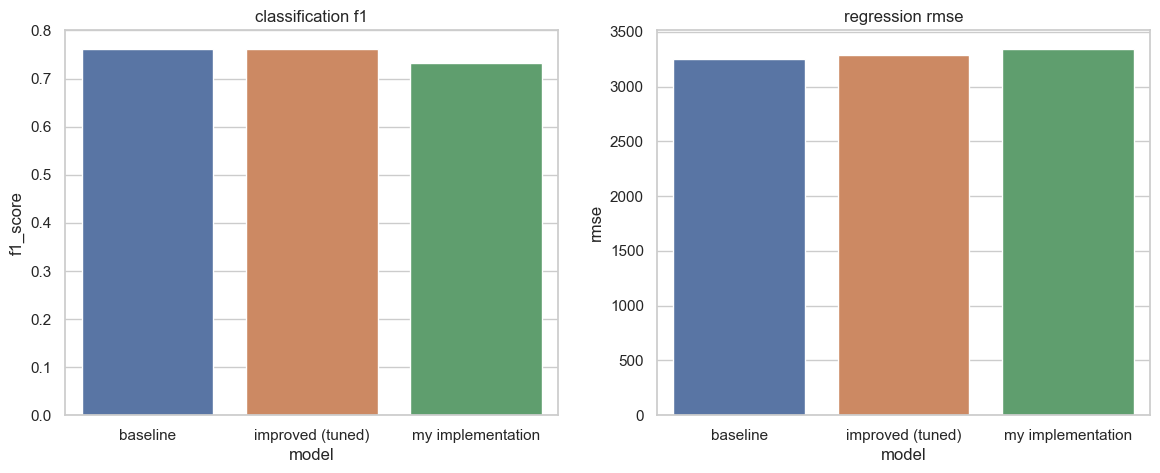

In [22]:
#визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='model', y='f1_score', data=results, ax=axes[0])
axes[0].set_title('classification f1')
sns.barplot(x='model', y='rmse', data=results, ax=axes[1])
axes[1].set_title('regression rmse')
plt.show()

In [23]:
#выводы
print("""
выводы по лр 4:
1. бейзлайн: случайный лес сразу показывает очень высокое качество, часто превосходящее одиночные деревья и линейные модели. это сила ансамблирования.
2. улучшение: случайный лес менее чувствителен к гиперпараметрам, чем одиночное дерево. подбор параметров дал небольшой прирост, но 'из коробки' алгоритм уже работает отлично.
3. реализация: бэггинг (бутстрап + агрегация) реализован успешно. метрики немного ниже библиотечных (из-за меньшего числа деревьев и отсутствия оптимизаций sklearn), но принцип работы продемонстрирован верно.
""")


выводы по лр 4:
1. бейзлайн: случайный лес сразу показывает очень высокое качество, часто превосходящее одиночные деревья и линейные модели. это сила ансамблирования.
2. улучшение: случайный лес менее чувствителен к гиперпараметрам, чем одиночное дерево. подбор параметров дал небольшой прирост, но 'из коробки' алгоритм уже работает отлично.
3. реализация: бэггинг (бутстрап + агрегация) реализован успешно. метрики немного ниже библиотечных (из-за меньшего числа деревьев и отсутствия оптимизаций sklearn), но принцип работы продемонстрирован верно.

